# NLP Advanced Project: Deceptive Opinion Spam Detection

## Objectives
1. **Exploratory Data Analysis (EDA)**: Characterize 'truthful' vs 'deceptive' reviews.
2. **Switch to PyTorch**: Implement a robust Bi-LSTM model.
3. **K-Fold Cross-Validation**: Address the small dataset size (1600 samples).
4. **BERT Comparison**: Fine-tune DistilBERT and compare it with the Bi-LSTM.
5. **Overfitting/Underfitting Analysis**: Visualize and interpret training curves.
6. **Interactive Interface**: Use Gradio for real-time review classification.

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.auto import tqdm
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Data Loading and Initial Exploration

In [14]:
# Download the dataset
path = kagglehub.dataset_download("rtatman/deceptive-opinion-spam-corpus")
csv_path = os.path.join(path, "deceptive-opinion.csv")
df = pd.read_csv(csv_path)

# Map labels: truthful -> 0, deceptive -> 1
df['label'] = df['deceptive'].map({'truthful': 0, 'deceptive': 1})

print(f"Dataset shape: {df.shape}")
df.head()

Using Colab cache for faster access to the 'deceptive-opinion-spam-corpus' dataset.
Dataset shape: (1600, 6)


,deceptive,hotel,polarity,source,text,label
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...,0
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...,0
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...,0
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...,0
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...,0


## 2. Characterizing True vs Fake Reviews
Let's analyze the text features to see if there are recognizable patterns in deceptive reviews.

In [15]:
def get_text_features(text):
    words = word_tokenize(text.lower())
    return {
        'length': len(text),
        'word_count': len(words),
        'punct_count': sum([1 for char in text if char in string.punctuation]),
        'stopword_count': sum([1 for word in words if word in stopwords.words('english')])
    }

features_df = df['text'].apply(lambda x: pd.Series(get_text_features(x)))
df_stats = pd.concat([df[['label']], features_df], axis=1)

# Comparison
comparison = df_stats.groupby('label').mean()
comparison.index = ['Truthful', 'Deceptive']
display(comparison)

,length,word_count,punct_count,stopword_count
Truthful,821.0150,171.5275,23.8700,74.9525
Deceptive,791.7675,163.4050,18.0225,75.8025


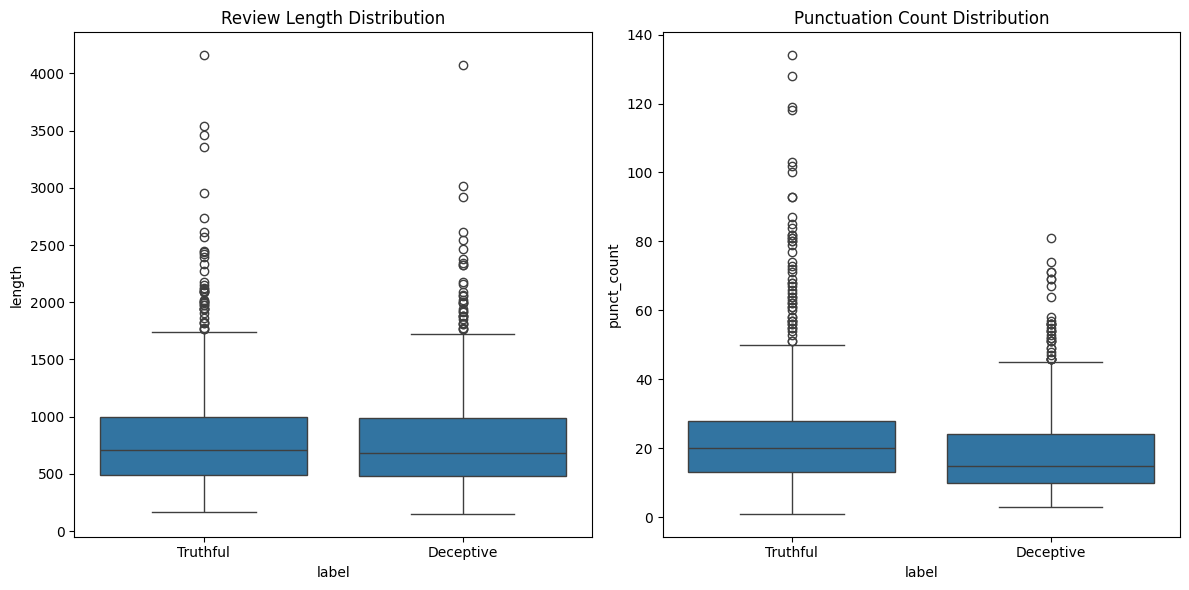

In [16]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='label', y='length', data=df_stats)
plt.title('Review Length Distribution')
plt.xticks([0, 1], ['Truthful', 'Deceptive'])

plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='punct_count', data=df_stats)
plt.title('Punctuation Count Distribution')
plt.xticks([0, 1], ['Truthful', 'Deceptive'])

plt.tight_layout()
plt.show()

## 3. PyTorch Bi-LSTM Implementation
We"ll start by preparing the vocabulary and the dataset pipeline.

In [17]:
from collections import Counter

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    return text

# Vocabulary Building
all_text = " ".join(df["text"].apply(clean_text))
words = all_text.split()
vocab = Counter(words)
vocab = sorted(vocab, key=vocab.get, reverse=True)
vocab_to_int = {word: ii + 1 for ii, word in enumerate(vocab[:10000])} # Limit to top 10k words
vocab_to_int["<PAD>"] = 0



In [18]:
vocab

['the',
 'and',
 'to',
 'a',
 'i',
 'was',
 'in',
 'of',
 'hotel',
 'we',
 'for',
 'room',
 'it',
 'at',
 'my',
 'is',
 'that',
 'with',
 'were',
 'not',
 'had',
 'this',
 'on',
 'chicago',
 'but',
 'our',
 'they',
 'very',
 'stay',
 'have',
 'there',
 'you',
 'be',
 'as',
 'from',
 'when',
 'all',
 'would',
 'great',
 'so',
 'staff',
 'me',
 'are',
 'service',
 'one',
 'rooms',
 'stayed',
 'an',
 'out',
 'no',
 'up',
 'us',
 'if',
 'like',
 'get',
 'will',
 'night',
 'just',
 'time',
 'about',
 'desk',
 'again',
 'nice',
 'or',
 'location',
 'after',
 'did',
 'even',
 'by',
 'which',
 'could',
 'bed',
 'only',
 'here',
 'also',
 'clean',
 'good',
 'got',
 'what',
 'back',
 'front',
 'more',
 'their',
 'some',
 'been',
 'place',
 'first',
 'hotels',
 'its',
 'bathroom',
 'experience',
 'next',
 'other',
 'well',
 'than',
 'day',
 'didnt',
 'really',
 'two',
 'because',
 'friendly',
 'never',
 'made',
 'comfortable',
 'go',
 'recommend',
 'business',
 'has',
 'do',
 'lobby',
 'staying',

In [19]:
def tokenize_text(text, max_len=200):
    text = clean_text(text)
    tokens = [vocab_to_int.get(word, 0) for word in text.split()][:max_len]
    # Padding
    if len(tokens) < max_len:
        tokens = tokens + [0] * (max_len - len(tokens))
    return tokens

df["tokenized"] = df["text"].apply(lambda x: tokenize_text(x))
print("Tokenization complete.")

Tokenization complete.


In [20]:
class ReviewDataset(Dataset):
    def __init__(self, tokenized_texts, labels):
        self.data = tokenized_texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.labels[idx]).float()

In [21]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=True,
                           dropout=dropout,
                           batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, seq_len, embedding_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # hidden shape: (num_layers * 2, batch_size, hidden_dim)

        # Concat the final forward and backward hidden states
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        # hidden shape: (batch_size, hidden_dim * 2)

        out = self.fc(hidden)
        return self.sigmoid(out)

In [22]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_losses = []
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(inputs).squeeze()
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            preds = (output > 0.5).float()
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        model.eval()
        val_losses = []
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                output = model(inputs).squeeze()
                loss = criterion(output, labels)
                val_losses.append(loss.item())
                preds = (output > 0.5).float()
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        history["train_loss"].append(np.mean(train_losses))
        history["val_loss"].append(np.mean(val_losses))
        history["train_acc"].append(correct_train / total_train)
        history["val_acc"].append(correct_val / total_val)

        if history["val_acc"][-1] > best_val_acc:
            best_val_acc = history["val_acc"][-1]
            torch.save(model.state_dict(), "best_lstm.pt")

    return history

In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

X = np.array(df["tokenized"].tolist())
y = df["label"].values

print("Starting K-Fold Cross Validation for Bi-LSTM...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/5")

    train_set = ReviewDataset(X[train_idx], y[train_idx])
    val_set = ReviewDataset(X[val_idx], y[val_idx])

    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=32)

    model = BiLSTMClassifier(len(vocab_to_int), 100, 128, 1, 2, 0.5).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=8)
    fold_results.append(history)
    print(f"Best Val Acc: {max(history["val_acc"]):.4f}")

Starting K-Fold Cross Validation for Bi-LSTM...
Fold 1/5
Best Val Acc: 0.7875
Fold 2/5
Best Val Acc: 0.7750
Fold 3/5
Best Val Acc: 0.8313
Fold 4/5
Best Val Acc: 0.7812
Fold 5/5
Best Val Acc: 0.7781


In [24]:
def plot_comparison(fold_results):
    avg_train_acc = np.mean([res["train_acc"] for res in fold_results], axis=0)
    avg_val_acc = np.mean([res["val_acc"] for res in fold_results], axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(avg_train_acc, label="Avg Train Accuracy")
    plt.plot(avg_val_acc, label="Avg Val Accuracy")
    plt.title("Bi-LSTM Performance: Train vs Validation (Overfitting analysis)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # If train accuracy >> val accuracy, we have overfitting.
    # If both are low, we have underfitting.

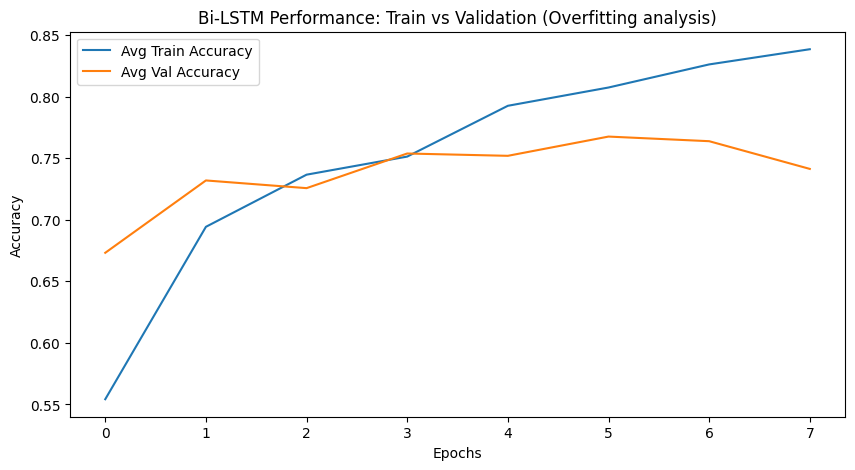

In [25]:
plot_comparison(fold_results)


ENTRAÎNEMENT DU MODÈLE BI-LSTM FINAL
Modèle chargé depuis best_lstm.pt

ÉVALUATION BI-LSTM

=== Métriques Train - Bi-LSTM ===
Accuracy: 0.8723
AUC-ROC: 0.9443

Classification Report:
               precision    recall  f1-score   support

 Truthful (0)       0.87      0.88      0.87       560
Deceptive (1)       0.88      0.87      0.87       560

     accuracy                           0.87      1120
    macro avg       0.87      0.87      0.87      1120
 weighted avg       0.87      0.87      0.87      1120



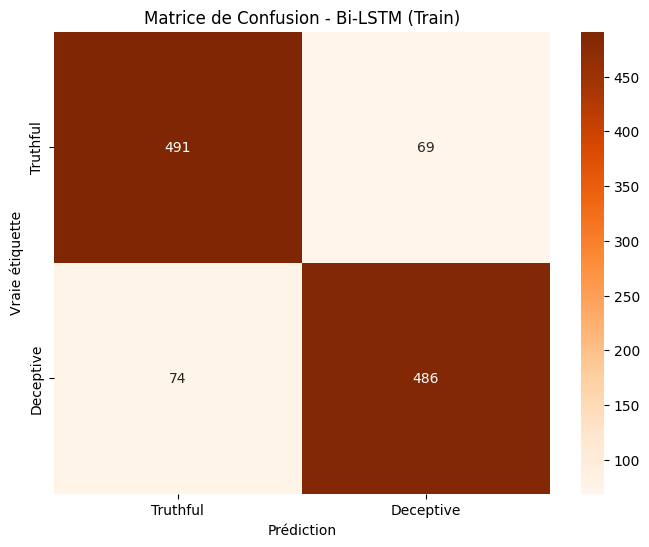


=== Métriques Validation - Bi-LSTM ===
Accuracy: 0.8500
AUC-ROC: 0.9279

Classification Report:
               precision    recall  f1-score   support

 Truthful (0)       0.89      0.80      0.84       120
Deceptive (1)       0.82      0.90      0.86       120

     accuracy                           0.85       240
    macro avg       0.85      0.85      0.85       240
 weighted avg       0.85      0.85      0.85       240



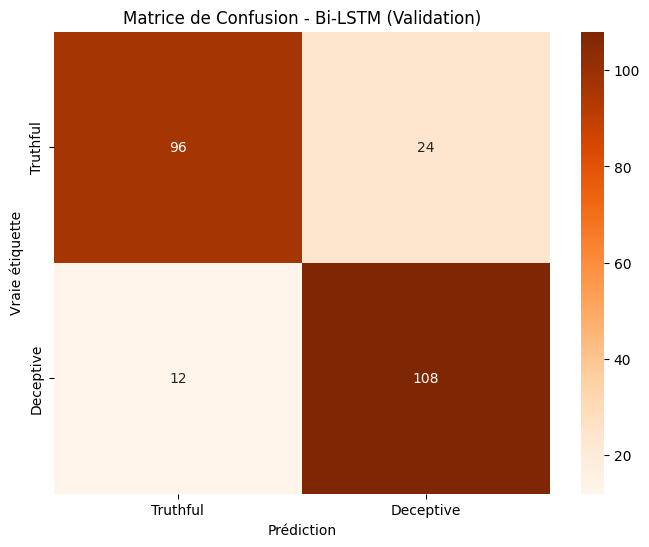


=== Métriques Test - Bi-LSTM ===
Accuracy: 0.8500
AUC-ROC: 0.9246

Classification Report:
               precision    recall  f1-score   support

 Truthful (0)       0.86      0.83      0.85       120
Deceptive (1)       0.84      0.87      0.85       120

     accuracy                           0.85       240
    macro avg       0.85      0.85      0.85       240
 weighted avg       0.85      0.85      0.85       240



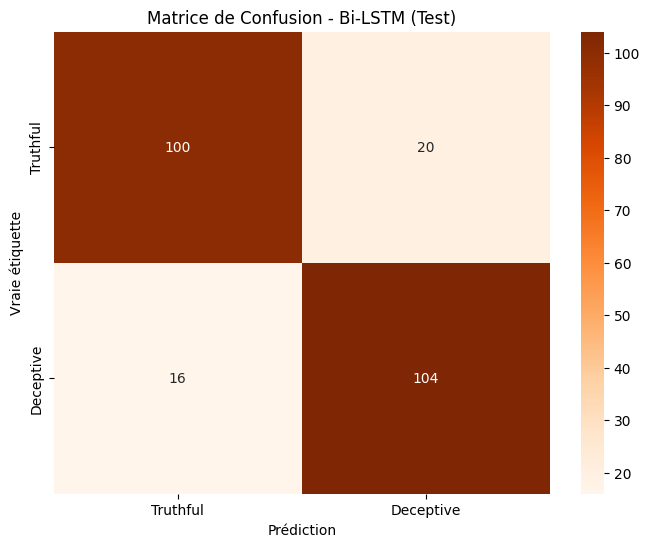


RÉSUMÉ BI-LSTM
Dataset         Accuracy     AUC-ROC     
---------------------------------------
Train           0.8723       0.9443
Validation      0.8500       0.9279
Test            0.8500       0.9246


In [26]:
def evaluate_lstm_model(model, data_loader, dataset_name="Validation"):
    """Évalue le modèle Bi-LSTM et retourne les métriques détaillées"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()

            probs = outputs.cpu().numpy()
            preds = (outputs > 0.5).float().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    # Calcul des métriques
    accuracy = accuracy_score(all_labels, all_preds)
    from sklearn.metrics import roc_auc_score # Import roc_auc_score here
    auc_roc = roc_auc_score(all_labels, all_probs)

    print(f"\n=== Métriques {dataset_name} - Bi-LSTM ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                              target_names=['Truthful (0)', 'Deceptive (1)']))

    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Truthful', 'Deceptive'],
                yticklabels=['Truthful', 'Deceptive'])
    plt.title(f'Matrice de Confusion - Bi-LSTM ({dataset_name})')
    plt.ylabel('Vraie étiquette')
    plt.xlabel('Prédiction')
    plt.show()

    return {
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'confusion_matrix': cm
    }

# Pour le Bi-LSTM, nous devons refaire un split train/val/test
# ou utiliser le dernier fold pour l'analyse détaillée

# 1. D'abord, créons un split train/val/test
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df['text'], df['label'], test_size=0.3, random_state=42, stratify=df['label']
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 2. Tokenisation
X_train_tokens = [tokenize_text(text) for text in X_train_text]
X_val_tokens = [tokenize_text(text) for text in X_val_text]
X_test_tokens = [tokenize_text(text) for text in X_test_text]

# 3. Création des datasets
train_dataset_lstm = ReviewDataset(X_train_tokens, y_train.values)
val_dataset_lstm = ReviewDataset(X_val_tokens, y_val.values)
test_dataset_lstm = ReviewDataset(X_test_tokens, y_test.values)

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=32, shuffle=True)
val_loader_lstm = DataLoader(val_dataset_lstm, batch_size=32)
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=32)

# 4. Entraînement d'un modèle final (ou chargement du meilleur)
print("\n" + "=" * 50)
print("ENTRAÎNEMENT DU MODÈLE BI-LSTM FINAL")
print("=" * 50)

model_lstm_final = BiLSTMClassifier(len(vocab_to_int), 100, 128, 1, 2, 0.5).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_lstm_final.parameters(), lr=0.001)

# Si vous avez sauvegardé le meilleur modèle pendant la CV, chargez-le
if os.path.exists("best_lstm.pt"):
    model_lstm_final.load_state_dict(torch.load("best_lstm.pt"))
    print("Modèle chargé depuis best_lstm.pt")
else:
    # Sinon, réentraînez
    history_final = train_model(model_lstm_final, train_loader_lstm, val_loader_lstm,
                                criterion, optimizer, epochs=8)

# 5. Évaluation
print("\n" + "=" * 50)
print("ÉVALUATION BI-LSTM")
print("=" * 50)

train_metrics_lstm = evaluate_lstm_model(model_lstm_final, train_loader_lstm, "Train")
val_metrics_lstm = evaluate_lstm_model(model_lstm_final, val_loader_lstm, "Validation")
test_metrics_lstm = evaluate_lstm_model(model_lstm_final, test_loader_lstm, "Test")

# Résumé comparatif
print("\n" + "=" * 50)
print("RÉSUMÉ BI-LSTM")
print("=" * 50)
print(f"{'Dataset':<15} {'Accuracy':<12} {'AUC-ROC':<12}")
print("-" * 39)
print(f"{'Train':<15} {train_metrics_lstm['accuracy']:.4f}       {train_metrics_lstm['auc_roc']:.4f}")
print(f"{'Validation':<15} {val_metrics_lstm['accuracy']:.4f}       {val_metrics_lstm['auc_roc']:.4f}")
print(f"{'Test':<15} {test_metrics_lstm['accuracy']:.4f}       {test_metrics_lstm['auc_roc']:.4f}")

## 4. DistilBERT Fine-Tuning Comparison
Now we use a pre-trained Transformer model for comparison.

In [27]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [28]:
def train_bert(model, train_loader, val_loader, optimizer, device, epochs=3):
    history = {"train_loss": [], "val_acc": []}
    for epoch in range(epochs):
        model.train()
        losses = []
        for batch in tqdm(train_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            losses.append(loss.item())

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                _, preds = torch.max(outputs.logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        history["train_loss"].append(np.mean(losses))
        history["val_acc"].append(correct / total)
        print(f"Epoch {epoch+1} - Loss: {history["train_loss"][-1]:.4f} - Val Acc: {history["val_acc"][-1]:.4f}")
    return history

In [29]:
# Séparation entraînement / validation (hold-out) pour DistilBERT
from sklearn.model_selection import train_test_split

# Redefine BertDataset class here to fix the AttributeError
# The original class in 'bert_prep' uses tokenizer.encode_plus, which is deprecated
# in newer versions of transformers. The direct call tokenizer(...) is now preferred.
class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

X_train_text, X_val_text, y_train, y_val = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# Création des datasets
train_dataset = BertDataset(X_train_text.values, y_train.values, tokenizer)
val_dataset = BertDataset(X_val_text.values, y_val.values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Chargement du modèle pré-entraîné
model_bert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)

optimizer = optim.AdamW(model_bert.parameters(), lr=2e-5)

# Entraînement
bert_history = train_bert(model_bert, train_loader, val_loader, optimizer, device, epochs=3)

print(f"Meilleure précision de validation pour DistilBERT : {max(bert_history['val_acc']):.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.5246 - Val Acc: 0.8562


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2640 - Val Acc: 0.9031


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 3 - Loss: 0.1569 - Val Acc: 0.8719
Meilleure précision de validation pour DistilBERT : 0.9031


## 5. Performance Comparison & Overfitting Analysis

In [30]:
def plot_comparison(fold_results):
    avg_train_acc = np.mean([res["train_acc"] for res in fold_results], axis=0)
    avg_val_acc = np.mean([res["val_acc"] for res in fold_results], axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(avg_train_acc, label="Avg Train Accuracy")
    plt.plot(avg_val_acc, label="Avg Val Accuracy")
    plt.title("Bi-LSTM Performance: Train vs Validation (Overfitting analysis)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # If train accuracy >> val accuracy, we have overfitting.
    # If both are low, we have underfitting.

Bi-LSTM (validation croisée) : précision moyenne = 0.7906
DistilBERT (hold-out) : meilleure précision de validation = 0.9031


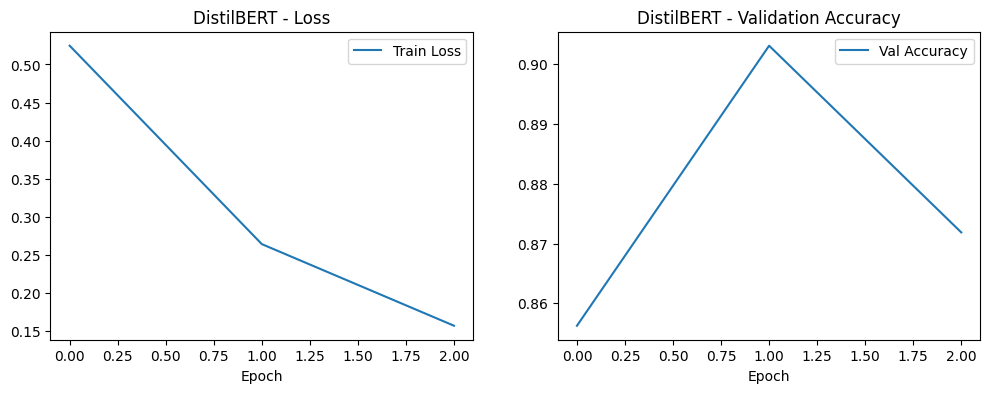

In [31]:
# Moyenne des performances du Bi-LSTM sur les 5 folds
avg_bilstm_val_acc = np.mean([max(res['val_acc']) for res in fold_results])
print(f"Bi-LSTM (validation croisée) : précision moyenne = {avg_bilstm_val_acc:.4f}")
print(f"DistilBERT (hold-out) : meilleure précision de validation = {max(bert_history['val_acc']):.4f}")

# Tracer l'évolution de la perte et de la précision pour DistilBERT
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(bert_history['train_loss'], label='Train Loss')
plt.title("DistilBERT - Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(bert_history['val_acc'], label='Val Accuracy')
plt.title("DistilBERT - Validation Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

ÉVALUATION DISTILBERT

=== Métriques Train - DistilBERT ===
Accuracy: 0.9805
AUC-ROC: 0.9989

Classification Report:
               precision    recall  f1-score   support

 Truthful (0)       1.00      0.96      0.98       640
Deceptive (1)       0.96      1.00      0.98       640

     accuracy                           0.98      1280
    macro avg       0.98      0.98      0.98      1280
 weighted avg       0.98      0.98      0.98      1280



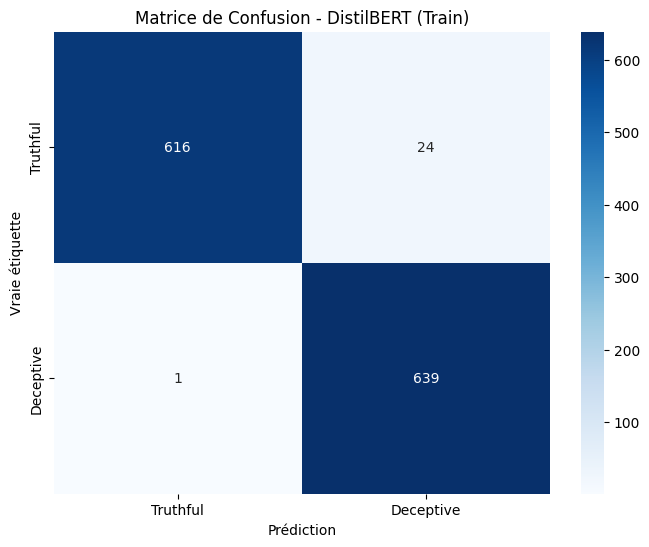


=== Métriques Validation - DistilBERT ===
Accuracy: 0.8719
AUC-ROC: 0.9575

Classification Report:
               precision    recall  f1-score   support

 Truthful (0)       0.95      0.79      0.86       160
Deceptive (1)       0.82      0.96      0.88       160

     accuracy                           0.87       320
    macro avg       0.88      0.87      0.87       320
 weighted avg       0.88      0.87      0.87       320



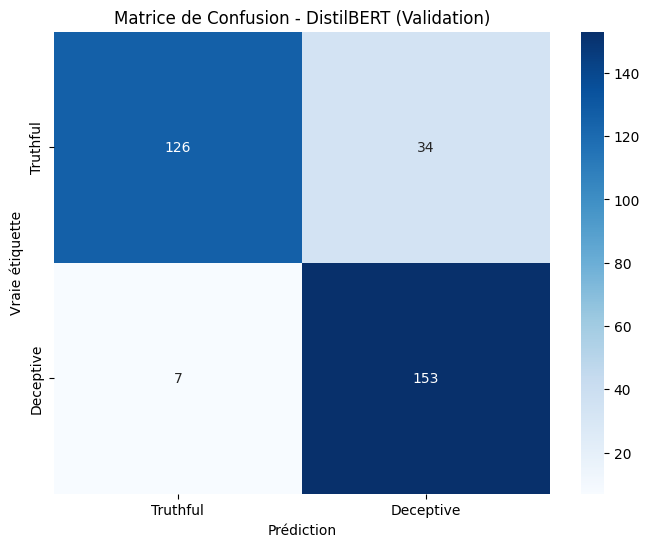


RÉSUMÉ DISTILBERT
Dataset         Accuracy     AUC-ROC     
---------------------------------------
Train           0.9805       0.9989
Validation      0.8719       0.9575


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_bert_model(model, data_loader, dataset_name="Validation"):
    """Évalue le modèle et retourne les métriques détaillées"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            _, preds = torch.max(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probabilité pour la classe positive

    # Calcul des métriques
    accuracy = accuracy_score(all_labels, all_preds)
    auc_roc = roc_auc_score(all_labels, all_probs)

    print(f"\n=== Métriques {dataset_name} - DistilBERT ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                              target_names=['Truthful (0)', 'Deceptive (1)']))

    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Truthful', 'Deceptive'],
                yticklabels=['Truthful', 'Deceptive'])
    plt.title(f'Matrice de Confusion - DistilBERT ({dataset_name})')
    plt.ylabel('Vraie étiquette')
    plt.xlabel('Prédiction')
    plt.show()

    return {
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'confusion_matrix': cm
    }

# Évaluation sur train, validation et test
print("=" * 50)
print("ÉVALUATION DISTILBERT")
print("=" * 50)

# Note: Vous devez créer un DataLoader pour l'entraînement aussi
train_loader_eval = DataLoader(train_dataset, batch_size=16)
val_loader_eval = DataLoader(val_dataset, batch_size=16)

# Si vous avez un ensemble de test séparé, sinon utilisez validation
# test_loader_eval = DataLoader(test_dataset, batch_size=16)

# Évaluation
train_metrics_bert = evaluate_bert_model(model_bert, train_loader_eval, "Train")
val_metrics_bert = evaluate_bert_model(model_bert, val_loader_eval, "Validation")
# test_metrics_bert = evaluate_bert_model(model_bert, test_loader_eval, "Test")

# Résumé comparatif
print("\n" + "=" * 50)
print("RÉSUMÉ DISTILBERT")
print("=" * 50)
print(f"{'Dataset':<15} {'Accuracy':<12} {'AUC-ROC':<12}")
print("-" * 39)
print(f"{'Train':<15} {train_metrics_bert['accuracy']:.4f}       {train_metrics_bert['auc_roc']:.4f}")
print(f"{'Validation':<15} {val_metrics_bert['accuracy']:.4f}       {val_metrics_bert['auc_roc']:.4f}")


COMPARAISON FINALE DES MODÈLES


,Modèle,Train Accuracy,Validation Accuracy,Test Accuracy,Train AUC-ROC,Validation AUC-ROC
0,Bi-LSTM,0.872321,0.850000,0.85,0.944295,0.927917
1,DistilBERT,0.980469,0.871875,N/A,0.998918,0.957500


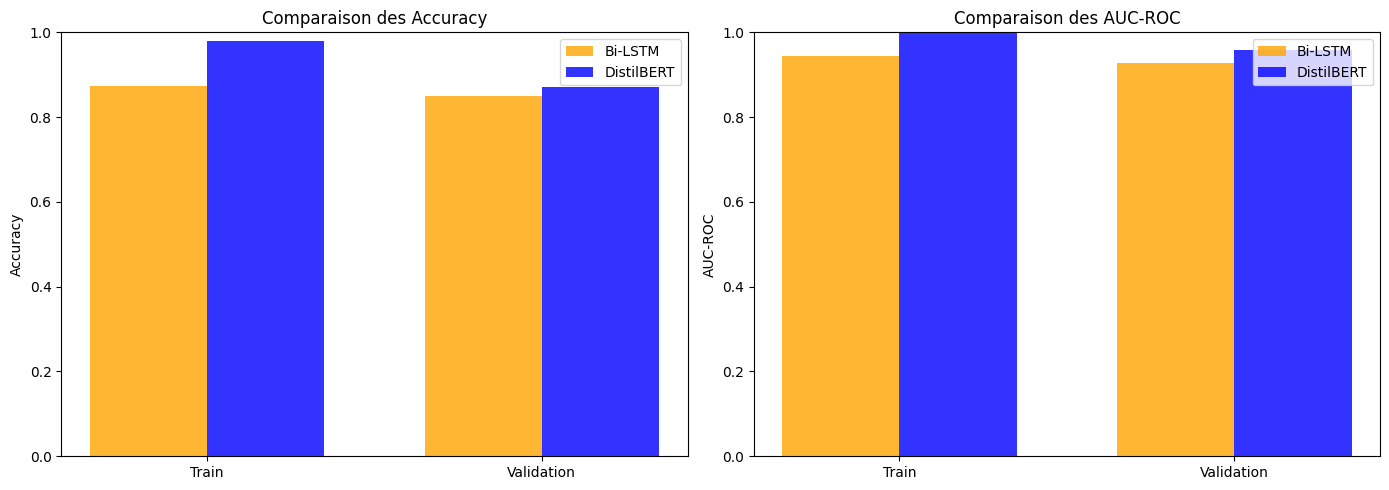


ANALYSE DU SURAPPRENTISSAGE

Bi-LSTM:
  Train Accuracy: 0.8723
  Val Accuracy: 0.8500
  Écart Train-Val: 0.0223
  ✅ Bon équilibre

DistilBERT:
  Train Accuracy: 0.9805
  Val Accuracy: 0.8719
  Écart Train-Val: 0.1086
  ⚠️  Surapprentissage détecté (écart > 0.1)


In [33]:
# Comparaison des performances
print("\n" + "=" * 60)
print("COMPARAISON FINALE DES MODÈLES")
print("=" * 60)

models_comparison = pd.DataFrame({
    'Modèle': ['Bi-LSTM', 'DistilBERT'],
    'Train Accuracy': [train_metrics_lstm['accuracy'], train_metrics_bert['accuracy']],
    'Validation Accuracy': [val_metrics_lstm['accuracy'], val_metrics_bert['accuracy']],
    'Test Accuracy': [test_metrics_lstm['accuracy'], 'N/A'],  # DistilBERT n'a pas de test ici
    'Train AUC-ROC': [train_metrics_lstm['auc_roc'], train_metrics_bert['auc_roc']],
    'Validation AUC-ROC': [val_metrics_lstm['auc_roc'], val_metrics_bert['auc_roc']]
})

display(models_comparison)

# Graphique de comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
datasets = ['Train', 'Validation']
x = np.arange(len(datasets))
width = 0.35

axes[0].bar(x - width/2,
            [models_comparison.loc[0, 'Train Accuracy'], models_comparison.loc[0, 'Validation Accuracy']],
            width, label='Bi-LSTM', color='orange', alpha=0.8)
axes[0].bar(x + width/2,
            [models_comparison.loc[1, 'Train Accuracy'], models_comparison.loc[1, 'Validation Accuracy']],
            width, label='DistilBERT', color='blue', alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison des Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets)
axes[0].legend()
axes[0].set_ylim([0, 1])

# AUC-ROC comparison
axes[1].bar(x - width/2,
            [models_comparison.loc[0, 'Train AUC-ROC'], models_comparison.loc[0, 'Validation AUC-ROC']],
            width, label='Bi-LSTM', color='orange', alpha=0.8)
axes[1].bar(x + width/2,
            [models_comparison.loc[1, 'Train AUC-ROC'], models_comparison.loc[1, 'Validation AUC-ROC']],
            width, label='DistilBERT', color='blue', alpha=0.8)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Comparaison des AUC-ROC')
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets)
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Analyse du surapprentissage
print("\n" + "=" * 60)
print("ANALYSE DU SURAPPRENTISSAGE")
print("=" * 60)

for model_name, train_acc, val_acc in [
    ('Bi-LSTM', train_metrics_lstm['accuracy'], val_metrics_lstm['accuracy']),
    ('DistilBERT', train_metrics_bert['accuracy'], val_metrics_bert['accuracy'])
]:
    gap = train_acc - val_acc
    print(f"\n{model_name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Val Accuracy: {val_acc:.4f}")
    print(f"  Écart Train-Val: {gap:.4f}")
    if gap > 0.1:
        print(f"  ⚠️  Surapprentissage détecté (écart > 0.1)")
    elif gap < -0.05:
        print(f"  ⚠️  Sous-apprentissage possible (val > train)")
    else:
        print(f"  ✅ Bon équilibre")

## 6. Interactive Interface
Finally, we'll create a simple interface to test the models.

In [34]:
pip install plotly gradio

In [ ]:
import gradio as gr
import torch
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Charger les modèles une seule fois au démarrage
print("Chargement des modèles...")

# Modèle Bi-LSTM
model_lstm = BiLSTMClassifier(len(vocab_to_int), 100, 128, 1, 2, 0.5).to(device)
if os.path.exists("best_lstm.pt"):
    model_lstm.load_state_dict(torch.load("best_lstm.pt", map_location=device))
model_lstm.eval()
print("✓ Bi-LSTM chargé")

# Modèle DistilBERT
try:
    if 'model_bert' in locals() or 'model_bert' in globals():
        model_bert.eval()
        print("✓ DistilBERT chargé")
    else:
        print(" DistilBERT non trouvé, veuillez l'entraîner d'abord")
        model_bert = None
except:
    model_bert = None
    print(" DistilBERT non disponible")

def predict_with_lstm(text):
    """Prédiction avec le modèle Bi-LSTM"""
    tokens = torch.tensor([tokenize_text(text)]).to(device)

    with torch.no_grad():
        prob = model_lstm(tokens).item()
        pred_class = 1 if prob > 0.5 else 0
        confidence = prob if prob > 0.5 else 1 - prob

    return {
        "prediction": pred_class,
        "label": "DECEPTIVE (FAKE)" if pred_class == 1 else "TRUTHFUL (REAL)",
        "confidence": confidence,
        "prob_deceptive": prob,
        "prob_truthful": 1 - prob
    }

def predict_with_bert(text):
    """Prédiction avec le modèle DistilBERT (version corrigée)"""
    if model_bert is None:
        return {
            "prediction": 0,
            "label": "MODEL NOT AVAILABLE",
            "confidence": 0,
            "prob_deceptive": 0,
            "prob_truthful": 0
        }

    # CORRECTION: utiliser __call__ au lieu de encode_plus
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=256,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model_bert(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        prob_deceptive = probs[0][1].item()
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    return {
        "prediction": pred_class,
        "label": "DECEPTIVE (FAKE)" if pred_class == 1 else "TRUTHFUL (REAL)",
        "confidence": confidence,
        "prob_deceptive": prob_deceptive,
        "prob_truthful": 1 - prob_deceptive
    }

def create_confidence_gauge(prob_deceptive, model_name):
    """Crée une jauge de confiance avec Plotly"""
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=prob_deceptive * 100,
        title={'text': f"Probabilité DECEPTIVE ({model_name})"},
        domain={'x': [0, 1], 'y': [0, 1]},
        gauge={
            'axis': {'range': [0, 100], 'tickwidth': 1},
            'bar': {'color': "darkred" if prob_deceptive > 0.5 else "darkgreen"},
            'steps': [
                {'range': [0, 50], 'color': "lightgreen"},
                {'range': [50, 100], 'color': "lightcoral"}
            ],
            'threshold': {
                'line': {'color': "black", 'width': 4},
                'thickness': 0.75,
                'value': 50
            }
        }
    ))

    fig.update_layout(height=300, margin=dict(l=20, r=20, t=50, b=20))
    return fig

# CORRECTION: La fonction ne retourne que 2 valeurs (markdown et plot)
def predict_review_advanced(text, model_choice):
    """Fonction principale de prédiction avec choix du modèle"""

    if not text or len(text.strip()) == 0:
        return "Veuillez entrer un texte à analyser", None

    # Prédiction selon le modèle choisi
    if model_choice == "Bi-LSTM":
        result = predict_with_lstm(text)
        model_name = "Bi-LSTM"
    else:  # DistilBERT
        result = predict_with_bert(text)
        model_name = "DistilBERT"

    # Création du texte de résultat
    result_text = f"""
## Résultat de l'analyse

**Modèle utilisé :** {model_name}
**Prédiction :** {result['label']}
**Confiance :** {result['confidence']*100:.2f}%

### Probabilités détaillées :
- Probabilité TRUTHFUL (réel) : {result['prob_truthful']*100:.2f}%
- Probabilité DECEPTIVE (fake) : {result['prob_deceptive']*100:.2f}%

### Analyse du texte :
**Longueur :** {len(text)} caractères, {len(text.split())} mots
    """

    # Création de la jauge
    gauge_fig = create_confidence_gauge(result['prob_deceptive'], model_name)

    # CORRECTION: Retourne seulement 2 valeurs
    return result_text, gauge_fig

# CORRECTION: Version simplifiée pour la comparaison
def compare_models(text):
    """Compare les prédictions des deux modèles"""
    if not text or len(text.strip()) == 0:
        return "Veuillez entrer un texte à comparer", None

    result_lstm = predict_with_lstm(text)
    result_bert = predict_with_bert(text) if model_bert is not None else None

    # Texte comparatif
    comparison_text = f"""
## Comparaison des modèles

### Bi-LSTM :
- **Prédiction :** {result_lstm['label']}
- **Confiance :** {result_lstm['confidence']*100:.2f}%
- Probabilité DECEPTIVE : {result_lstm['prob_deceptive']*100:.2f}%

    """

    if result_bert and result_bert['label'] != "MODEL NOT AVAILABLE":
        agreement = "✅ Les modèles sont d'accord" if result_lstm['prediction'] == result_bert['prediction'] else "❌ Les modèles sont en désaccord"
        comparison_text += f"""
### DistilBERT :
- **Prédiction :** {result_bert['label']}
- **Confiance :** {result_bert['confidence']*100:.2f}%
- Probabilité DECEPTIVE : {result_bert['prob_deceptive']*100:.2f}%

### Verdict : {agreement}
        """

        # Graphique comparatif
        fig = make_subplots(rows=1, cols=2,
                           subplot_titles=("Bi-LSTM", "DistilBERT"),
                           specs=[[{'type': 'domain'}, {'type': 'domain'}]])

        fig.add_trace(go.Pie(labels=['Truthful', 'Deceptive'],
                             values=[result_lstm['prob_truthful']*100, result_lstm['prob_deceptive']*100],
                             marker_colors=['lightgreen', 'lightcoral'],
                             name="Bi-LSTM"), 1, 1)

        fig.add_trace(go.Pie(labels=['Truthful', 'Deceptive'],
                             values=[result_bert['prob_truthful']*100, result_bert['prob_deceptive']*100],
                             marker_colors=['lightgreen', 'lightcoral'],
                             name="DistilBERT"), 1, 2)

        fig.update_layout(height=400, showlegend=False)
        return comparison_text, fig
    else:
        comparison_text += "\n DistilBERT non disponible"
        return comparison_text, None

# Création de l'interface avancée avec onglets
with gr.Blocks(title="Détecteur d'avis trompeurs", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    #  Détecteur d'avis trompeurs (Opinion Spam Detection)

    Cette application utilise deux modèles de deep learning pour détecter si un avis est authentique ou trompeur :
    - **Bi-LSTM** : Réseau de neurones récurrent
    - **DistilBERT** : Modèle transformer pré-entraîné

    Entrez un avis d'hôtel ci-dessous pour l'analyser !
    """)

    with gr.Tabs():
        with gr.TabItem(" Prédiction simple"):
            with gr.Row():
                with gr.Column(scale=2):
                    text_input = gr.Textbox(
                        lines=5,
                        placeholder="Entrez un avis d'hôtel à analyser...",
                        label="Texte de l'avis"
                    )
                    model_selector = gr.Radio(
                        choices=["Bi-LSTM", "DistilBERT"],
                        value="Bi-LSTM",
                        label="Choisir le modèle"
                    )
                    predict_btn = gr.Button("Analyser", variant="primary")

                with gr.Column(scale=1):
                    model_status = gr.JSON(label="État des modèles", value={
                        "Bi-LSTM": "✅ Chargé",
                        "DistilBERT": "✅ Chargé" if model_bert else "❌ Non disponible"
                    })

            with gr.Row():
                with gr.Column(scale=1):
                    result_output = gr.Markdown(label="Résultat")
                with gr.Column(scale=1):
                    gauge_output = gr.Plot(label="Jauge de confiance")

            # Exemples préchargés
            gr.Examples(
                examples=[
                    ["The room was clean but smaller than expected. Bed comfortable, AC worked well but wifi was spotty. Good value for $89.", "Bi-LSTM"],
                    ["This hotel is ABSOLUTELY PERFECT!!! Best hotel EVER!!! 10 STARS!!! MUST STAY HERE!!!", "DistilBERT"],
                ],
                inputs=[text_input, model_selector],
                outputs=[result_output, gauge_output],
                fn=predict_review_advanced,
                cache_examples=False
            )

        with gr.TabItem(" Comparaison des modèles"):
            with gr.Row():
                text_compare = gr.Textbox(
                    lines=5,
                    placeholder="Entrez un avis pour comparer les deux modèles...",
                    label="Texte à comparer"
                )

            compare_btn = gr.Button("Comparer les modèles", variant="primary")

            with gr.Row():
                comparison_result = gr.Markdown(label="Résultat de la comparaison")

            with gr.Row():
                comparison_plot = gr.Plot(label="Comparaison visuelle")

    # Liaison des événements
    predict_btn.click(
        fn=predict_review_advanced,
        inputs=[text_input, model_selector],
        outputs=[result_output, gauge_output]
    )

    compare_btn.click(
        fn=compare_models,
        inputs=[text_compare],
        outputs=[comparison_result, comparison_plot]
    )

# Lancement de l'interface
if __name__ == "__main__":
    demo.launch(share=False, debug=True)

Chargement des modèles...
✓ Bi-LSTM chargé
✓ DistilBERT chargé


/tmp/ipython-input-1742421871.py:202: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Détecteur d'avis trompeurs", theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>